# Лабораторная работа №6
## Ансамбли моделей машинного обучения. Часть 2.

**Цель:** изучение ансамблей моделей машинного обучения (стекинг, MLP).

**Датасет:** Diabetes — предсказание прогрессии диабета (регрессия).

---

## Импорт библиотек и загрузка данных

In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.neural_network import MLPRegressor

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 100

import warnings
warnings.filterwarnings('ignore')

In [34]:
# Загрузка датасета
diabetes = load_diabetes()

df = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)
df['target'] = diabetes.target

print(f"Размер датасета: {df.shape}")
print(f"Целевая переменная: прогрессия диабета (количественная переменная)")
print("\nПервые 5 строк:")
df.head()

Размер датасета: (442, 11)
Целевая переменная: прогрессия диабета (количественная переменная)

Первые 5 строк:


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


In [35]:
print("Описательная статистика:")
df.describe()

Описательная статистика:


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
count,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,442.000000
mean,-2.511817e-19,1.230790e-17,-2.245564e-16,-4.797570e-17,-1.381499e-17,3.918434e-17,-5.777179e-18,-9.042540e-18,9.268604e-17,1.130318e-17,152.133484
std,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,77.093005
min,-1.072256e-01,-4.464164e-02,-9.027530e-02,-1.123988e-01,-1.267807e-01,-1.156131e-01,-1.023071e-01,-7.639450e-02,-1.260971e-01,-1.377672e-01,25.000000
25%,-3.729927e-02,-4.464164e-02,-3.422907e-02,-3.665608e-02,-3.424784e-02,-3.035840e-02,-3.511716e-02,-3.949338e-02,-3.324559e-02,-3.317903e-02,87.000000
50%,5.383060e-03,-4.464164e-02,-7.283766e-03,-5.670422e-03,-4.320866e-03,-3.819065e-03,-6.584468e-03,-2.592262e-03,-1.947171e-03,-1.077698e-03,140.500000
75%,3.807591e-02,5.068012e-02,3.124802e-02,3.564379e-02,2.835801e-02,2.984439e-02,2.931150e-02,3.430886e-02,3.243232e-02,2.791705e-02,211.500000
max,1.107267e-01,5.068012e-02,1.705552e-01,1.320436e-01,1.539137e-01,1.987880e-01,1.811791e-01,1.852344e-01,1.335973e-01,1.356118e-01,346.000000


In [36]:
# Проверка пропусков и дубликатов
print(f"Пропуски: {df.isnull().sum().sum()}")
print(f"Дубликаты: {df.duplicated().sum()}")

Пропуски: 0
Дубликаты: 0


## Подготовка данных

In [37]:
X = df[diabetes.feature_names].values
y = df['target'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Масштабирование
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Размер обучающей выборки: {X_train_scaled.shape}")
print(f"Размер тестовой выборки: {X_test_scaled.shape}")

Размер обучающей выборки: (353, 10)
Размер тестовой выборки: (89, 10)


## Обучение моделей

### 1. Stacking (Стекинг)

In [38]:
# Реализация Stacking регрессора
class StackingRegressor:
    """Простая реализация стекинга для регрессии"""
    def __init__(self, base_models, meta_model):
        self.base_models = base_models
        self.meta_model = meta_model
        
    def fit(self, X, y):
        # Обучаем базовые модели и получаем их предсказания
        meta_features = np.zeros((X.shape[0], len(self.base_models)))
        
        for i, model in enumerate(self.base_models):
            model.fit(X, y)
            meta_features[:, i] = model.predict(X)
        
        # Обучаем мета-модель на предсказаниях базовых моделей
        self.meta_model.fit(meta_features, y)
        return self
    
    def predict(self, X):
        # Получаем предсказания от базовых моделей
        meta_features = np.zeros((X.shape[0], len(self.base_models)))
        
        for i, model in enumerate(self.base_models):
            meta_features[:, i] = model.predict(X)
        
        # Предсказания мета-модели
        return self.meta_model.predict(meta_features)

# Создаём базовые модели
base_models = [
    LinearRegression(),
    Ridge(alpha=1.0),
    Ridge(alpha=10.0),
    Ridge(alpha=100.0)
]

# Мета-модель
meta_model = Ridge(alpha=1.0)

# Обучаем stacking модель
stacking_model = StackingRegressor(base_models, meta_model)
stacking_model.fit(X_train_scaled, y_train)

# Предсказания
y_pred_stacking = stacking_model.predict(X_test_scaled)

# Оценка качества
mse_stacking = mean_squared_error(y_test, y_pred_stacking)
mae_stacking = mean_absolute_error(y_test, y_pred_stacking)
r2_stacking = r2_score(y_test, y_pred_stacking)

print(f"Stacking Regressor:")
print(f"  MSE: {mse_stacking:.4f}")
print(f"  MAE: {mae_stacking:.4f}")
print(f"  R²: {r2_stacking:.4f}")

Stacking Regressor:
  MSE: 2900.2397
  MAE: 42.7941
  R²: 0.4526


### 2. Многослойный персептрон (MLP)

In [39]:
# Обучение MLP регрессора
mlp_model = MLPRegressor(
    hidden_layer_sizes=(100, 100, 50),
    activation='relu',
    solver='adam',
    max_iter=1000,
    random_state=42,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=50,
    verbose=0
)

mlp_model.fit(X_train_scaled, y_train)

# Предсказания
y_pred_mlp = mlp_model.predict(X_test_scaled)

# Оценка качества
mse_mlp = mean_squared_error(y_test, y_pred_mlp)
mae_mlp = mean_absolute_error(y_test, y_pred_mlp)
r2_mlp = r2_score(y_test, y_pred_mlp)

print(f"MLP Regressor:")
print(f"  Архитектура: {X_train_scaled.shape[1]} -> 100 -> 100 -> 50 -> 1")
print(f"  MSE: {mse_mlp:.4f}")
print(f"  MAE: {mae_mlp:.4f}")
print(f"  R²: {r2_mlp:.4f}")
print(f"  Итераций обучено: {mlp_model.n_iter_}")

MLP Regressor:
  Архитектура: 10 -> 100 -> 100 -> 50 -> 1
  MSE: 2939.1337
  MAE: 43.5136
  R²: 0.4453
  Итераций обучено: 219


## Сравнение моделей

In [40]:
# Создание сводной таблицы
results = pd.DataFrame({
    'Модель': [
        'Stacking',
        'MLP Regressor',
    ],
    'MSE': [mse_stacking, mse_mlp],
    'MAE': [mae_stacking, mae_mlp],
    'R²': [r2_stacking, r2_mlp]
})

print("\n" + "=" * 90)
print("СРАВНЕНИЕ ВСЕХ МОДЕЛЕЙ")
print("=" * 90)
print(results.to_string(index=False))
print("=" * 90)

# Лучшая модель по каждой метрике
best_mse_idx = results['MSE'].idxmin()
best_r2_idx = results['R²'].idxmax()

print(f"\n🏆 Лучшая по MSE: {results.loc[best_mse_idx, 'Модель']} (MSE={results.loc[best_mse_idx, 'MSE']:.4f})")
print(f"🏆 Лучшая по R²: {results.loc[best_r2_idx, 'Модель']} (R²={results.loc[best_r2_idx, 'R²']:.4f})")


СРАВНЕНИЕ ВСЕХ МОДЕЛЕЙ
       Модель         MSE       MAE       R²
     Stacking 2900.239694 42.794100 0.452594
MLP Regressor 2939.133668 43.513619 0.445253

🏆 Лучшая по MSE: Stacking (MSE=2900.2397)
🏆 Лучшая по R²: Stacking (R²=0.4526)


### Визуализация результатов

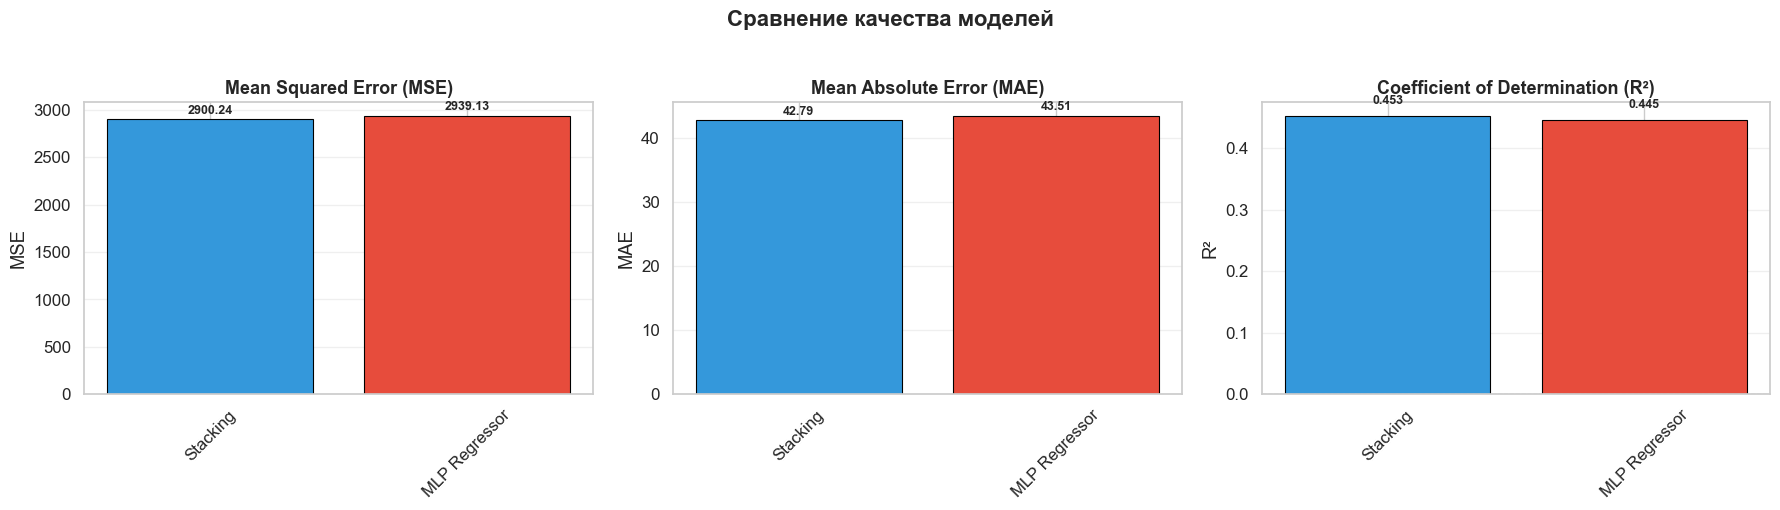

In [41]:
# Визуализация метрик
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

models = results['Модель'].values
colors_models = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12']

# MSE
axes[0].bar(models, results['MSE'], color=colors_models, edgecolor='black', linewidth=0.8)
axes[0].set_title('Mean Squared Error (MSE)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('MSE')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(axis='y', alpha=0.3)
for i, v in enumerate(results['MSE']):
    axes[0].text(i, v + max(results['MSE'])*0.02, f'{v:.2f}', ha='center', fontweight='bold', fontsize=9)

# MAE
axes[1].bar(models, results['MAE'], color=colors_models, edgecolor='black', linewidth=0.8)
axes[1].set_title('Mean Absolute Error (MAE)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('MAE')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(axis='y', alpha=0.3)
for i, v in enumerate(results['MAE']):
    axes[1].text(i, v + max(results['MAE'])*0.02, f'{v:.2f}', ha='center', fontweight='bold', fontsize=9)

# R²
axes[2].bar(models, results['R²'], color=colors_models, edgecolor='black', linewidth=0.8)
axes[2].set_title('Coefficient of Determination (R²)', fontsize=13, fontweight='bold')
axes[2].set_ylabel('R²')
axes[2].tick_params(axis='x', rotation=45)
axes[2].grid(axis='y', alpha=0.3)
axes[2].axhline(y=0, color='black', linestyle='--', linewidth=0.8)
for i, v in enumerate(results['R²']):
    axes[2].text(i, v + 0.02, f'{v:.3f}', ha='center', fontweight='bold', fontsize=9)

fig.suptitle('Сравнение качества моделей', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

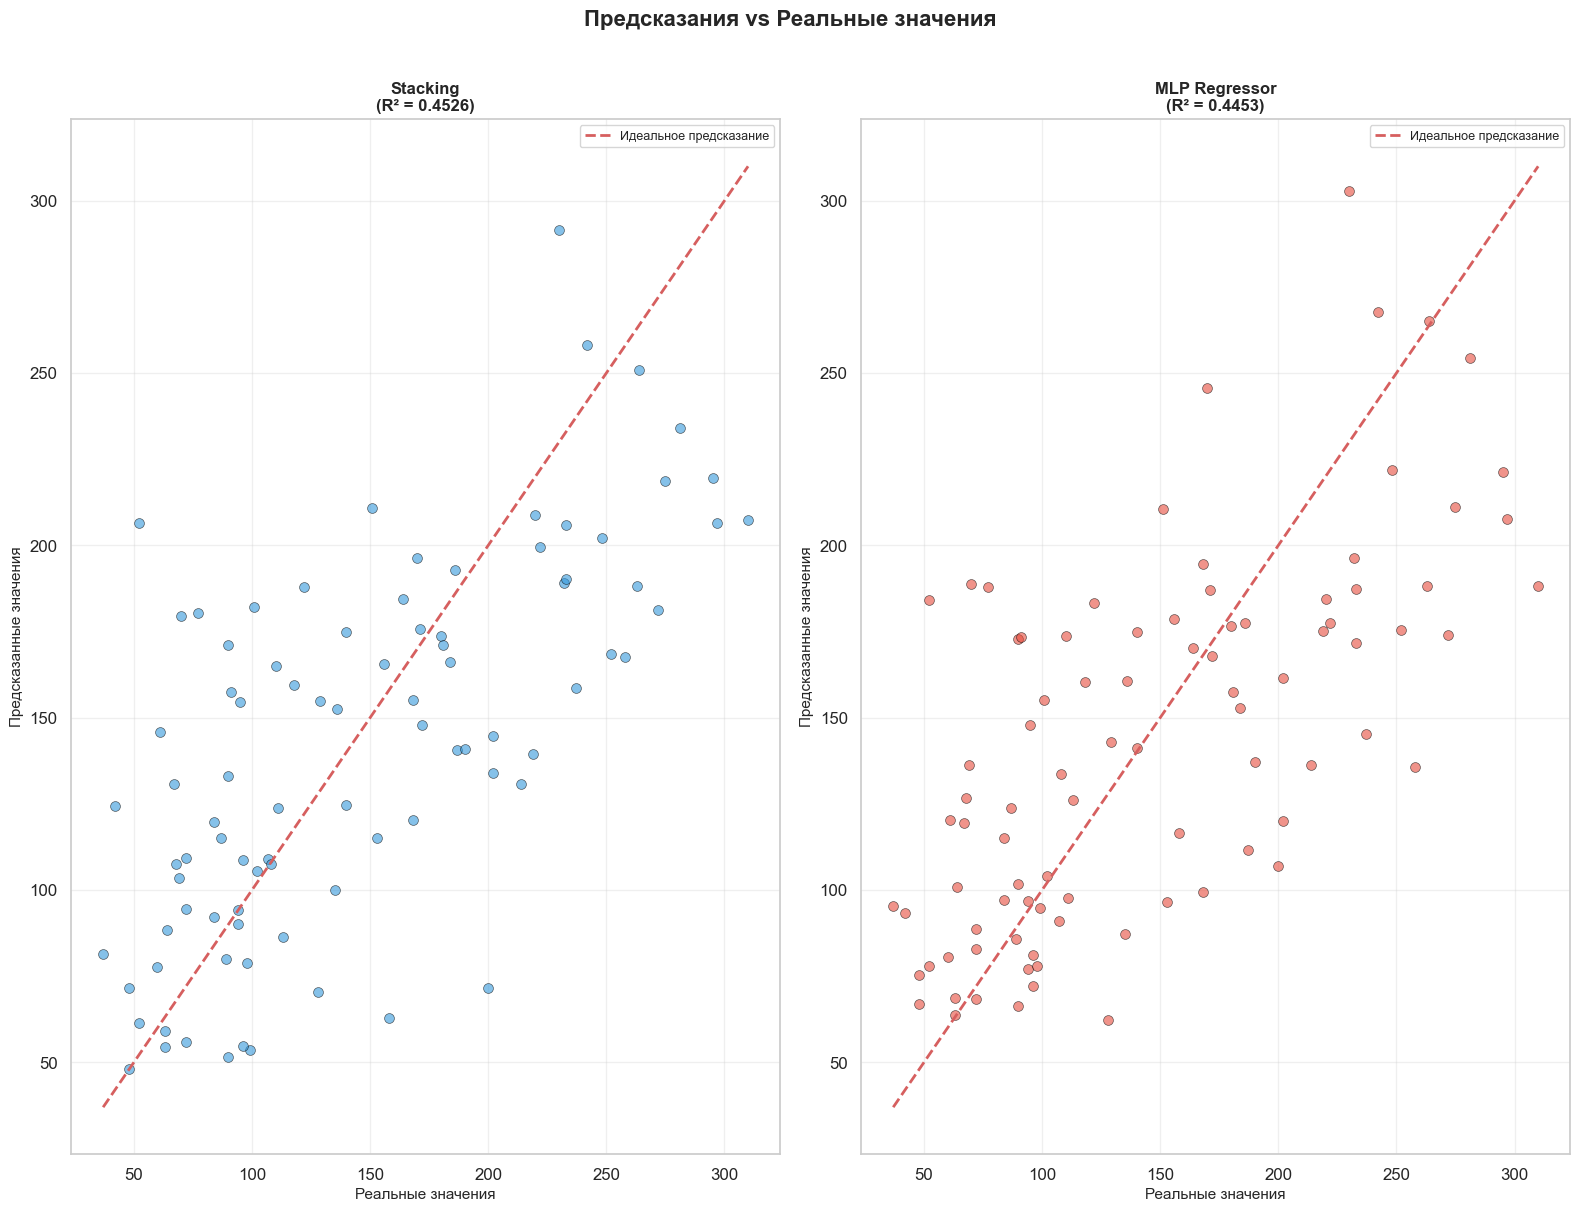

In [42]:
# Визуализация предсказаний vs реальные значения
fig, axes = plt.subplots(1, 2, figsize=(16, 12))
axes = axes.flatten()

predictions = [y_pred_stacking, y_pred_mlp]
model_names = ['Stacking', 'MLP Regressor']
r2_scores = [r2_stacking, r2_mlp]

for ax, pred, name, color, r2 in zip(axes, predictions, model_names, colors_models, r2_scores):
    ax.scatter(y_test, pred, alpha=0.6, s=50, color=color, edgecolors='black', linewidth=0.5)
    
    # Линия идеального предсказания
    min_val = min(y_test.min(), pred.min())
    max_val = max(y_test.max(), pred.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Идеальное предсказание')
    
    ax.set_xlabel('Реальные значения', fontsize=11)
    ax.set_ylabel('Предсказанные значения', fontsize=11)
    ax.set_title(f'{name}\n(R² = {r2:.4f})', fontsize=12, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

fig.suptitle('Предсказания vs Реальные значения', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

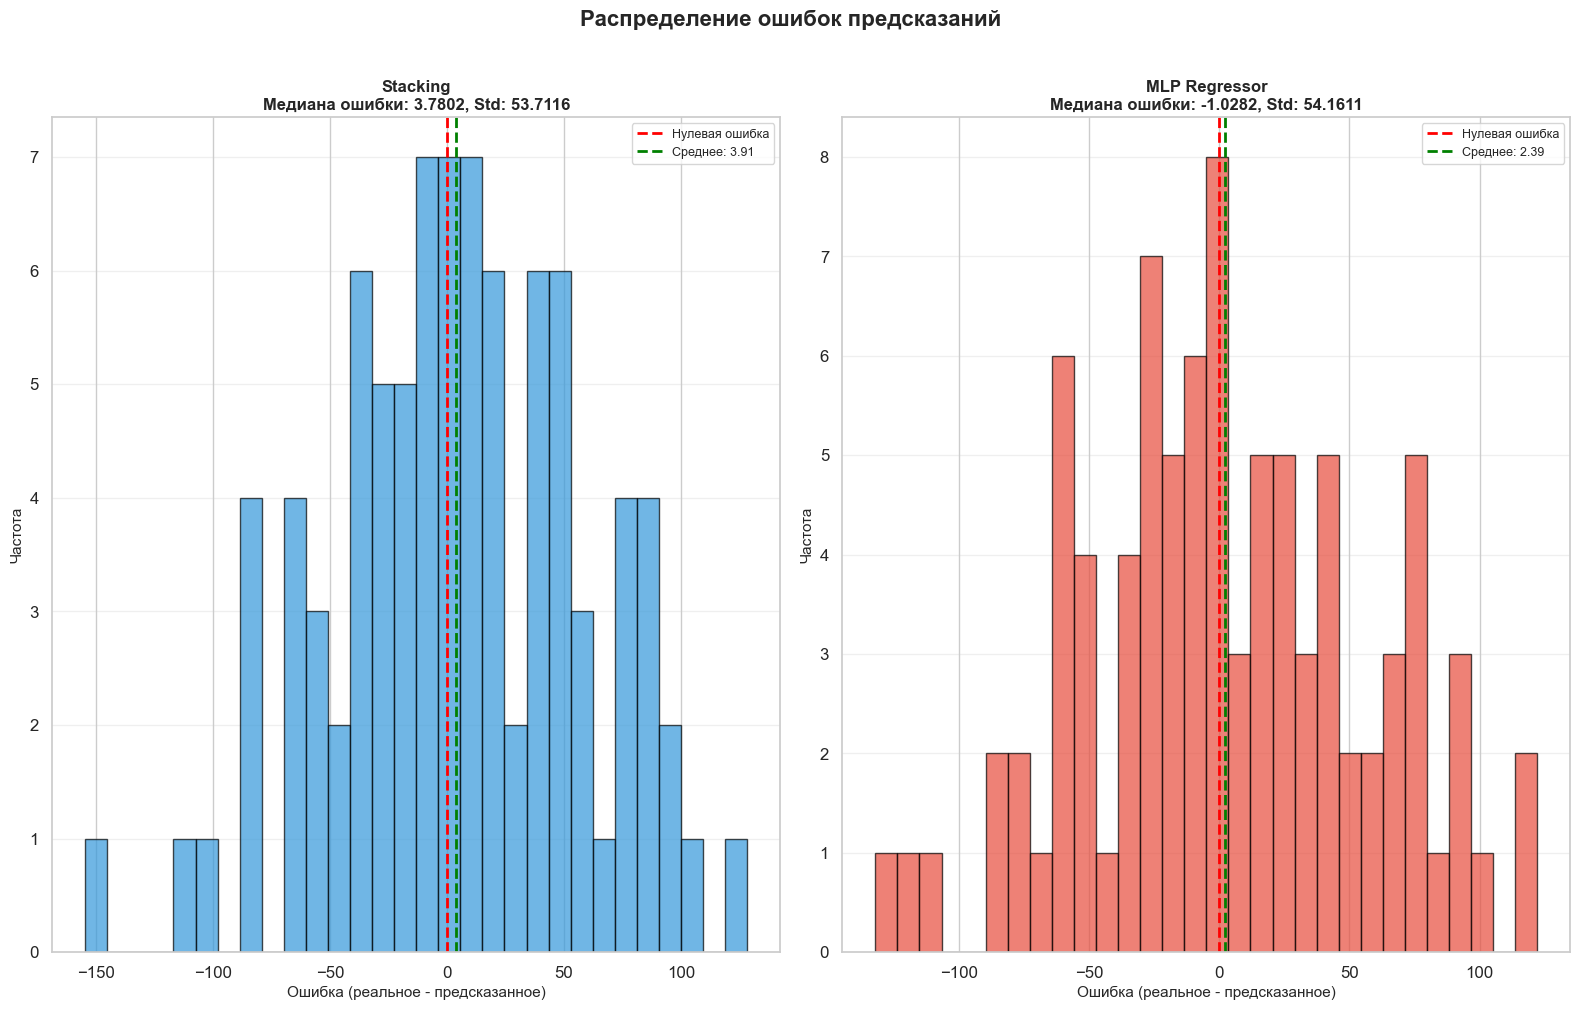

In [43]:
# Анализ ошибок
fig, axes = plt.subplots(1, 2, figsize=(16, 10))
axes = axes.flatten()

for ax, pred, name, color in zip(axes, predictions, model_names, colors_models):
    errors = y_test - pred
    
    ax.hist(errors, bins=30, color=color, edgecolor='black', alpha=0.7)
    ax.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Нулевая ошибка')
    ax.axvline(x=np.mean(errors), color='green', linestyle='--', linewidth=2, label=f'Среднее: {np.mean(errors):.2f}')
    
    ax.set_xlabel('Ошибка (реальное - предсказанное)', fontsize=11)
    ax.set_ylabel('Частота', fontsize=11)
    ax.set_title(f'{name}\nМедиана ошибки: {np.median(errors):.4f}, Std: {np.std(errors):.4f}', fontsize=12, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.3)

fig.suptitle('Распределение ошибок предсказаний', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()